# Set up and data load

## Imports

In [1]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#1. Serie caracterization &2. smothing and decomposition
from statsmodels.tsa.seasonal import seasonal_decompose # Classic Decomposition (Aditive or Multiplicative)
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing # Exponential smoothing models (Holt-Winters)
from statsmodels.tsa.api import SimpleExpSmoothing, Holt
from scipy.stats import pearsonr
#3. ARIMA SARIMA models
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Diagnostic graphics
from statsmodels.tsa.stattools import adfuller # Stacionarity tests (Essential before ARIMA)
from statsmodels.tsa.statespace.sarimax import SARIMAX # SARIMA model
from statsmodels.stats.diagnostic import acorr_ljungbox # Diagnostic test Ljung-Box (Residuals from the do modelo)
#4.  Compare the forecasting results obtained using the different approaches. & 5. Obtain out-of-sample point and 95% prediction intervals using the different approaches.
from sklearn.metrics import mean_squared_error, mean_absolute_error # Evaluation metrics for scenarios



**Imports Notes**

Dica extra: Se quiser automatizar a procura do melhor valor de baseado no menor valor de AIC, a biblioteca externa pmdarima (com a função auto_arima) poupa imenso trabalho manual de tentativa e erro [Geeksforgeeks time series analysis and forecasteoin](https://www.google.com/url?sa=i&source=web&rct=j&url=https://www.geeksforgeeks.org/machine-learning/time-series-analysis-and-forecasting/&ved=2ahUKEwj1iobTgr6UAxWrQ6QEHU0pPfwQ0YISegYIAAgeEAI&opi=89978449&cd&psig=AOvVaw3dSKLDCFQcliazRLtM_C5z&ust=1779028205357000)

Para calcular as métricas de erro no conjunto de teste (como RMSE ou MAE) e extrair os intervalos de previsão de 95% solicitados: [towards data science](https://www.google.com/url?sa=i&source=web&rct=j&url=https://towardsdatascience.com/time-series-analysis-arima-based-models-541de9c7b4db/&ved=2ahUKEwj1iobTgr6UAxWrQ6QEHU0pPfwQ0YISegYIAAgiEAE&opi=89978449&cd&psig=AOvVaw3dSKLDCFQcliazRLtM_C5z&ust=1779028205357000)

## Plot Settings

In [2]:
# Reset to Matplotlib default style
plt.style.use("default")

# University palette
UNI_COLORS = {
    "light_grey": "#A8A9A7",
    "dark_grey": "#767775",
    "red": "#FF3444",
    "pink": "#F8CACC",
    "soft_grey": "#D9D9D8",
}

# Global plotting configuration
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 140,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": UNI_COLORS["dark_grey"],
    "axes.labelcolor": UNI_COLORS["dark_grey"],
    "axes.titlecolor": UNI_COLORS["dark_grey"],
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.color": UNI_COLORS["dark_grey"],
    "ytick.color": UNI_COLORS["dark_grey"],
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.grid": False,
    "grid.alpha": 0.0,
    "legend.frameon": False,
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "lines.linewidth": 2.0,
})

def style_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(UNI_COLORS["dark_grey"])
    ax.spines["bottom"].set_color(UNI_COLORS["dark_grey"])
    ax.tick_params(colors=UNI_COLORS["dark_grey"])

## Data and Output paths

In [3]:
data_path = Path('../00_DATA/passageiros_transportados_ferroviario_ligeiro.xlsx')
table_path = Path('../01_OUTPUTS/Porto_Metro.xlsx')
fig_path = Path('../01_OUTPUTS/FIGURES')

## Functions

### Function to calculate metrics:  
Error, ME (Mean Error), MAE (Mean Absolute Error), MSE (Mean Square Error), MAPE (Mean Absolute % Error), correlation between the observation and the forecast


In [31]:
def calculate_metrics(y_true, y_pred):
    # Alinha e remove NaNs para garantir que calculamos métricas em dados válidos comuns
    mask = y_true.notna() & y_pred.notna()
    yt = y_true[mask]
    yp = y_pred[mask]
    
    if len(yt) < 2:
        return [np.nan] * 5
    
    # Cálculos das métricas
    errors = yt - yp
    mae = np.mean(np.abs(errors))
    mse = np.mean(errors ** 2)
    #mape = np.mean(np.abs(errors / yt)) * 100
    non_zero_mask = yt != 0
    if np.any(non_zero_mask):
        mape = np.mean(np.abs(errors[non_zero_mask] / yt[non_zero_mask])) * 100
    else:
        mape = np.nan
    
    corr, _ = pearsonr(yt, yp)
    r_quadrado = corr ** 2
    
    return [np.mean(errors), mae, mse, mape, corr, r_quadrado]


## Read raw data & configure


In [4]:
raw = pd.read_excel(
    data_path, 
    sheet_name="Quadro", 
    skiprows = 4
    )

raw = raw.iloc[:, 0:2]
raw.columns = ['Date', 'Nr']
raw = raw.dropna(subset=['Date', 'Nr'])
raw['Nr'] = pd.to_numeric(raw['Nr'], errors='coerce')
meses_pt = {
    'janeiro de ': '01-', 'fevereiro de ': '02-', 'março de ': '03-', 'abril de ': '04-',
    'maio de ': '05-', 'junho de ': '06-', 'julho de ': '07-', 'agosto de ': '08-',
    'setembro de ': '09-', 'outubro de ': '10-', 'novembro de ': '11-', 'dezembro de ': '12-'
}

raw['Date'] = raw['Date'].astype(str).str.lower().str.strip()
for mes_nome, mes_num in meses_pt.items():
    raw['Date'] = raw['Date'].str.replace(mes_nome, mes_num, regex=False)

raw['Date'] = pd.to_datetime(raw['Date'], format='%m-%Y', errors='coerce')

raw = raw.dropna(subset=['Date'])

raw.set_index('Date', inplace = True)

raw = raw.sort_index()

raw.index = raw.index.tz_localize('Europe/Lisbon', ambiguous='infer')
#raw.set_index('Date', inplace = True)

#raw.index.freq = 'MS'
raw = raw.asfreq('MS')

raw.head(15)

,Nr
Date,
2004-01-01 00:00:00+00:00,588.0
2004-02-01 00:00:00+00:00,548.0
2004-03-01 00:00:00+00:00,654.0
2004-04-01 00:00:00+01:00,603.0
2004-05-01 00:00:00+01:00,700.0
2004-06-01 00:00:00+01:00,1056.0
2004-07-01 00:00:00+01:00,931.0
2004-08-01 00:00:00+01:00,767.0
2004-09-01 00:00:00+01:00,923.0


# 1. Features of the time series

## Plot Metro passangers Time series - raw data

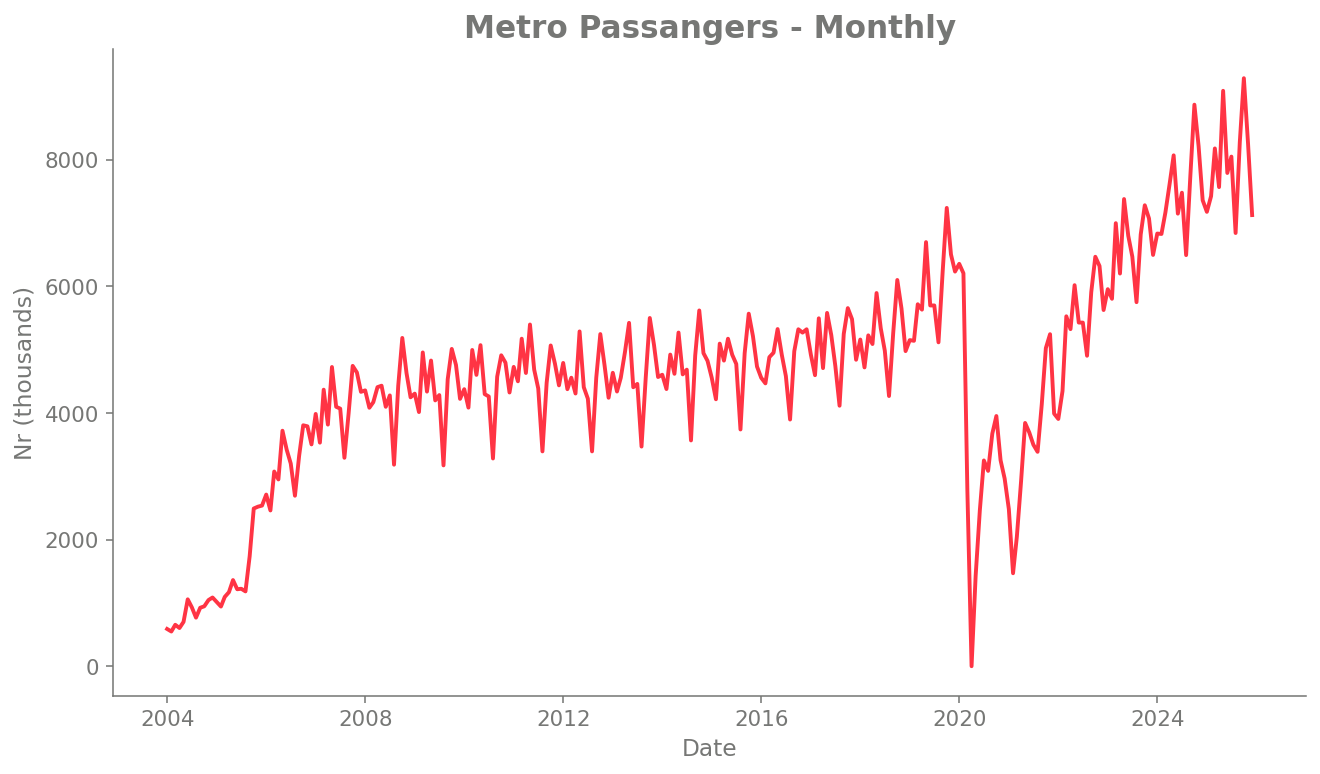

In [5]:

fig, ax = plt.subplots()

ax.plot(raw.index, raw['Nr'], color=UNI_COLORS["red"], label="Passageiros")

style_axis(ax)

ax.set_title("Metro Passangers - Monthly")
ax.set_xlabel("Date")
ax.set_ylabel("Nr (thousands)")

plt.savefig(f"{fig_path}/00_time_serie.png", dpi=300)
plt.show()


## Resample

monthly original data with Anual and Quarter average of the data for general overview of the data

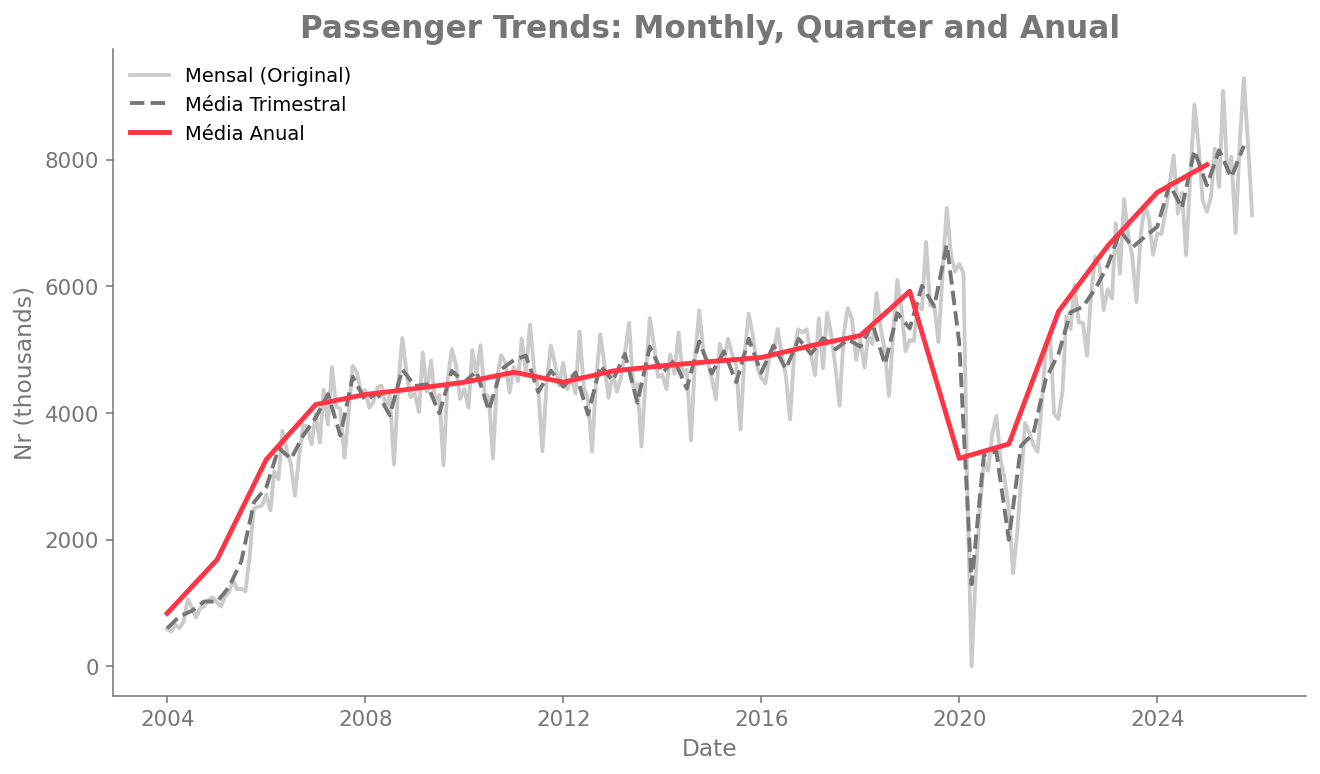

In [6]:

df_trimestral = raw['Nr'].resample('BQS').mean().to_frame(name='Av_Quarter')
df_trimestral['Year'] = df_trimestral.index.year
df_trimestral['Quarter'] = df_trimestral.index.quarter

df_anual = raw['Nr'].resample('BYS').mean().to_frame(name='Av_Anual')
df_anual['Year'] = df_anual.index.year


df_resample = pd.merge(df_trimestral, df_anual, on='Year', how='left')


df_resample = df_resample[['Year', 'Quarter', 'Av_Quarter', 'Av_Anual']]

df_resample.reset_index(drop=True, inplace=True)

with pd.ExcelWriter(table_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    df_resample.to_excel(writer, sheet_name='Resample')

#print("--- Estrutura da nova folha de médias ---")
#print(df_resample.head(8))


fig, ax = plt.subplots()

ax.plot(
    raw.index, raw['Nr'], 
    color=UNI_COLORS["light_grey"], 
    alpha=0.6, 
    label="Mensal (Original)"
)

raw_trimestral = raw['Nr'].resample('BQS').mean()
ax.plot(
    raw_trimestral.index, raw_trimestral, 
    color=UNI_COLORS["dark_grey"], 
    linestyle="--", 
    label="Média Trimestral"
)

raw_anual = raw['Nr'].resample('BYS').mean()
ax.plot(
    raw_anual.index, raw_anual, 
    color=UNI_COLORS["red"], 
    linewidth=2.5, 
    label="Média Anual"
)

style_axis(ax)

ax.set_title("Passenger Trends: Monthly, Quarter and Anual")
ax.set_xlabel("Date")
ax.set_ylabel("Nr (thousands)")

ax.legend(loc="upper left")

plt.savefig(f"{fig_path}/01_Resampling_Anual_Quarter_Month.png", dpi=300)
plt.show()

# 2.     Analysis and forecasts  

##2.1. Smothing moving average  
A lógica matemática por trás dos valores escolhidos:
1. Bloco Anual (alpha =0.15)
Na suavização exponencial, o peso do passado decai geometricamente. Existe uma aproximação clássica que converte o tamanho de uma janela de média móvel (N) num valor de alpha equivalente: alpha = 2/n+1

Se queremos uma suavização equivalente a 12 meses (
N=12): alpha =2/(12+1) =0.1538

Daí a escolha de 0.15. Este valor garante que o modelo dá pouco peso ao mês anterior e distribui a importância ao longo de todo o ano passado, gerando uma linha de tendência suave.
2. Bloco Trimestral (alpha=0.65)
Aplicando a mesma fórmula para uma janela de 3 meses (N=3): alpha = 2/(3+1) = 0.5
Escolhi 0.65 (um pouco acima de 0.50) para garantir que o modelo exponencial seja visivelmente mais "nervoso" e reativo do que a média móvel correspondente [1], captando rapidamente desvios abruptos na procura do metro de mês para mês.
3. Parâmetro de Tendência do Holt (beta=0.05 e beta=0.3)  
O coeficiente beta controla a velocidade com que a inclinação da tendência se altera.

    No bloco Anual (0.05), queremos que a tendência subjacente mude de forma muito lenta e estável.
    No bloco Trimestral (0.30), permitimos que o modelo assuma inversões de tendência rápidas a cada mudança de estação do ano.

**Como tornar isto 100% rigoroso** para o seu relatório? (Sem inventar valores)
Se não quiser usar valores fixos "estipulados" por si no relatório, pode pedir ao Python para otimizar os parâmetros com restrições, ou seja, encontrar matematicamente o melhor
possível, mas limitando a procura a intervalos lógicos.
Pode fazê-lo utilizando o método padrão .fit() mas adicionando limites (bounds) suportados pelo statsmodels:

In [39]:
y = raw['Nr'].copy()

# --- 1. LMA Simples(One-step-ahead shift) ---
ma_12 = y.rolling(window=12).mean().shift(1)
ma_3 = y.rolling(window=3).mean().shift(1)

# --- 2. Combined LMA MA(r x r) ---
# MA(2x12) Anual: MA of 12 months, followed by 2 months average to center
ma_2x12 = y.rolling(window=12).mean().rolling(window=2).mean().shift(1)

# MA(2x4) Quarter: MA of 4 months, centred with 2 months
ma_2x4 = y.rolling(window=4).mean().rolling(window=2).mean().shift(1)

# MA(3x3) Quarter: MA of 3 months , followed by 3 months to center
ma_3x3 = y.rolling(window=3).mean().rolling(window=3).mean().shift(1)

# --- 3. Single Exponential Smoothing (SES) ---
ses_12_model = SimpleExpSmoothing(y).fit(smoothing_level=0.15, optimized=False)
ses_12 = ses_12_model.fittedvalues
# SES Anual: Obriga o algoritmo a procurar um alfa que suavize a séria a longo prazo
#ses_op_12_model = SimpleExpSmoothing(y).fit(
#    minimize_kwargs={"bounds": [(0.05, 0.25), (None, None)]} # Limita o alfa, deixa o nível livre
#)
#ses_op_12 = ses_op_12_model.fittedvalues

ses_3_model = SimpleExpSmoothing(y).fit(smoothing_level=0.65, optimized=False)
ses_3 = ses_3_model.fittedvalues

# SES Trimestral: Obriga o algoritmo a focar apenas no curto prazo
#ses_op_3_model = SimpleExpSmoothing(y).fit(
#    minimize_kwargs={"bounds": [(0.50, 0.85), (None, None)]}
#)
#ses_op_3 = ses_op_3_model.fittedvalues

# --- 4. Double Exponential Smoothing (Holt's Linear Trend) ---
holt_12_model = Holt(y).fit(smoothing_level=0.15, smoothing_trend=0.05, optimized=False)
holt_12 = holt_12_model.fittedvalues

holt_3_model = Holt(y).fit(smoothing_level=0.65, smoothing_trend=0.30, optimized=False)
holt_3 = holt_3_model.fittedvalues

# --- 5. Dataframe ---
df_smoothing = pd.DataFrame(index=raw.index)
df_smoothing['Raw_Data'] = y

# Bloco Anual
df_smoothing['S_MA_A'] = raw['Nr'].rolling(window=12).mean()
df_smoothing['MA_A'] = ma_12
df_smoothing['MA_2x12_A'] = ma_2x12
df_smoothing['SES_A'] = ses_12
#df_smoothing['SES_OP_A'] = ses_op_12
df_smoothing['Holt_A'] = holt_12

# Bloco Trimestral
df_smoothing['S_MA_Q'] = raw['Nr'].rolling(window=3).mean()
df_smoothing['MA_Q'] = ma_3
df_smoothing['MA_2x4_Q'] = ma_2x4
df_smoothing['MA_3x3_Q'] = ma_3x3
df_smoothing['SES_Q'] = ses_3
#df_smoothing['SES_OP_Q'] = ses_op_3
df_smoothing['Holt_Q'] = holt_3

df_excel = df_smoothing.copy()

df_excel.index = df_excel.index.tz_localize(None)
with pd.ExcelWriter(table_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    df_excel.to_excel(writer, sheet_name='Smoothing_Previsoes')

df_smoothing.head(13)


,Raw_Data,S_MA_A,MA_A,MA_2x12_A,SES_A,Holt_A,S_MA_Q,MA_Q,MA_2x4_Q,MA_3x3_Q,SES_Q,Holt_Q
Date,,,,,,,,,,,,
2004-01-01 00:00:00+00:00,588.0,NaN,NaN,NaN,588.000000,548.000000,NaN,NaN,NaN,NaN,588.000000,548.000000
2004-02-01 00:00:00+00:00,548.0,NaN,NaN,NaN,588.000000,514.300000,NaN,NaN,NaN,NaN,588.000000,541.800000
2004-03-01 00:00:00+00:00,654.0,NaN,NaN,NaN,582.000000,479.907750,596.666667,NaN,NaN,NaN,562.000000,514.839000
2004-04-01 00:00:00+01:00,603.0,NaN,NaN,NaN,592.800000,467.880029,601.666667,596.666667,NaN,NaN,621.800000,601.439045
2004-05-01 00:00:00+01:00,700.0,NaN,NaN,NaN,594.330000,451.019867,652.333333,601.666667,NaN,NaN,609.580000,598.903447
2004-06-01 00:00:00+01:00,1056.0,NaN,NaN,NaN,610.180500,453.106079,786.333333,652.333333,612.250,616.888889,668.353000,680.779816
2004-07-01 00:00:00+01:00,931.0,NaN,NaN,NaN,677.053425,512.801064,895.666667,786.333333,689.750,680.111111,920.323550,1014.004480
2004-08-01 00:00:00+01:00,767.0,NaN,NaN,NaN,715.145411,547.928294,918.000000,895.666667,787.875,778.111111,927.263242,1033.197240
2004-09-01 00:00:00+01:00,923.0,NaN,NaN,NaN,722.923600,554.829477,873.666667,918.000000,843.000,866.666667,823.092135,881.406243


### Plot raw data vs moving average

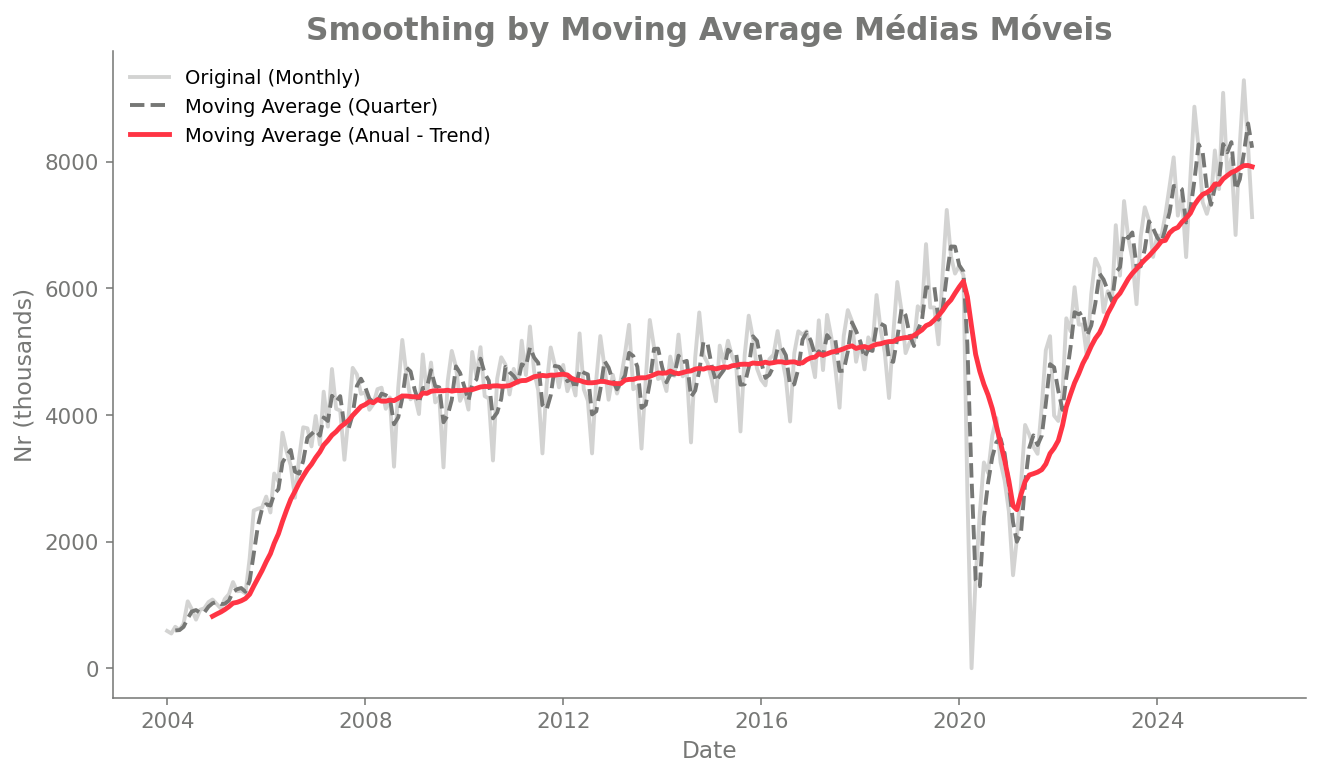

In [40]:
fig, ax = plt.subplots()

# Série Original
ax.plot(
    df_smoothing.index, df_smoothing['Raw_Data'], 
    color=UNI_COLORS["light_grey"], alpha=0.5, label="Original (Monthly)"
)

# Média Móvel Trimestral (Janela de 3 meses para captar flutuações de curto prazo)
ax.plot(
    df_smoothing.index, df_smoothing['S_MA_Q'], 
    color=UNI_COLORS["dark_grey"], linestyle="--", label="Moving Average (Quarter)"
)

# Média Móvel Anual (Janela de 12 meses para isolar a tendência pura e remover a sazonalidade)
ax.plot(
    df_smoothing.index, df_smoothing['S_MA_A'], 
    color=UNI_COLORS["red"], linewidth=2.5, label="Moving Average (Anual - Trend)"
)

# Aplicar o seu estilo e eixos personalizados
style_axis(ax)

# Configurações textuais
ax.set_title("Smoothing by Moving Average Médias Móveis")
ax.set_xlabel("Date")
ax.set_ylabel("Nr (thousands)")
ax.legend(loc="upper left")

# Gravar o gráfico numa única linha
plt.savefig(f"{fig_path}/02_smoothing_moving_average.png", dpi=300)
plt.show()

### Plot Soothing forecast Vs raw data

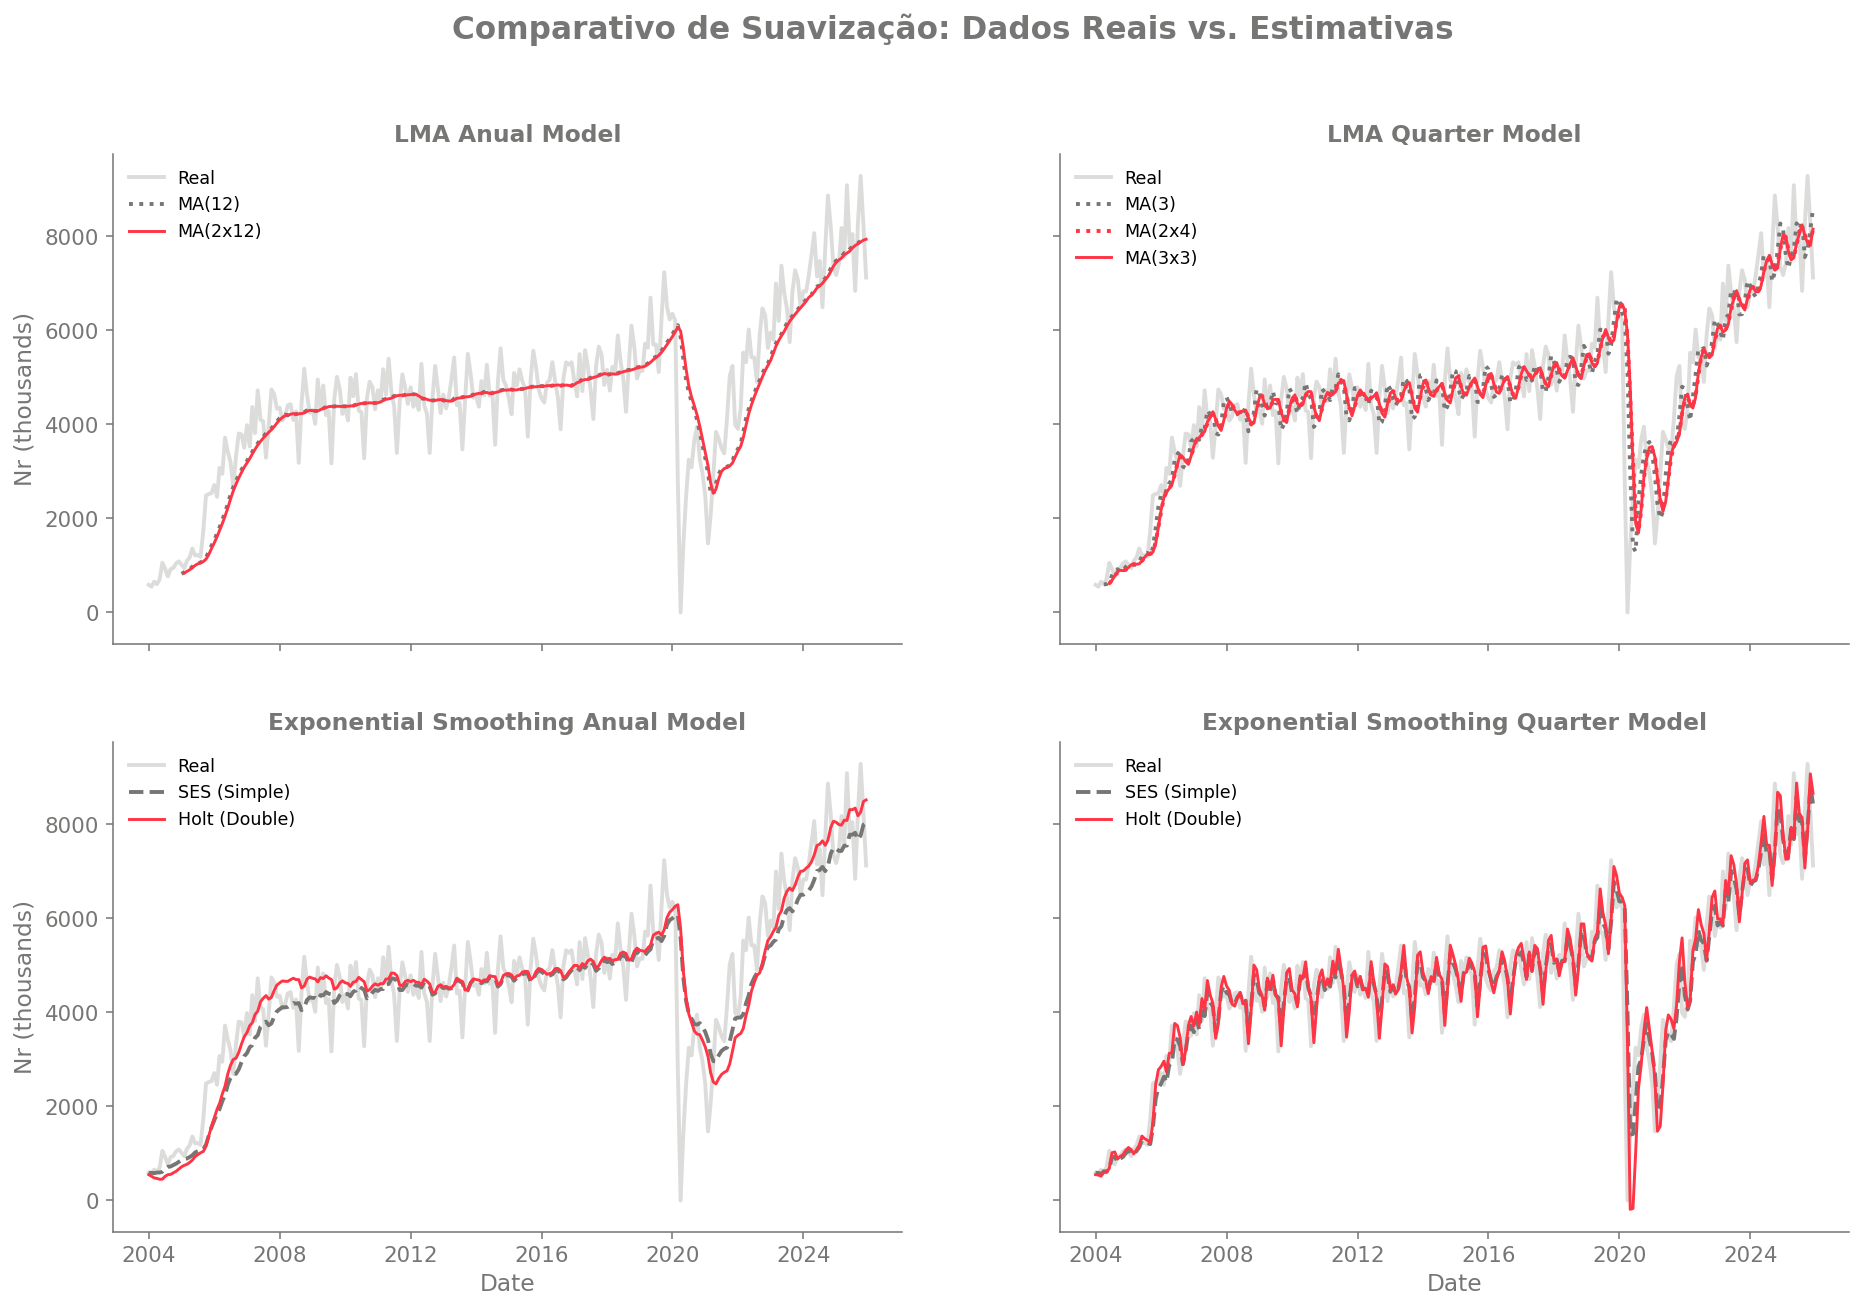

In [43]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10), sharex=True, sharey=True)

(ax1, ax2), (ax3, ax4) = axes

# --- QUADRANTE 1: Anual Linear (Cima-Esquerda) ---
ax1.plot(df_smoothing.index, df_smoothing['Raw_Data'], color=UNI_COLORS["light_grey"], alpha=0.4, label="Real")
ax1.plot(df_smoothing.index, df_smoothing['MA_A'], color=UNI_COLORS["dark_grey"], linestyle=":", label="MA(12)")
ax1.plot(df_smoothing.index, df_smoothing['MA_2x12_A'], color=UNI_COLORS["red"], linewidth=1.5, label="MA(2x12)")
ax1.set_title("LMA Anual Model", fontsize=12, weight='bold')
ax1.legend(loc="upper left", fontsize=9)
style_axis(ax1)

# --- QUADRANTE 2: Trimestral Linear (Cima-Direita) ---
ax2.plot(df_smoothing.index, df_smoothing['Raw_Data'], color=UNI_COLORS["light_grey"], alpha=0.4, label="Real")
ax2.plot(df_smoothing.index, df_smoothing['MA_Q'], color=UNI_COLORS["dark_grey"], linestyle=":", label="MA(3)")
ax2.plot(df_smoothing.index, df_smoothing['MA_2x4_Q'], color=UNI_COLORS["red"], linestyle=":", label="MA(2x4)")
ax2.plot(df_smoothing.index, df_smoothing['MA_3x3_Q'], color=UNI_COLORS["red"], linewidth=1.5, label="MA(3x3)")
ax2.set_title("LMA Quarter Model", fontsize=12, weight='bold')
ax2.legend(loc="upper left", fontsize=9)
style_axis(ax2)

# --- QUADRANTE 3: Anual Exponencial (Baixo-Esquerda) ---
ax3.plot(df_smoothing.index, df_smoothing['Raw_Data'], color=UNI_COLORS["light_grey"], alpha=0.4, label="Real")
ax3.plot(df_smoothing.index, df_smoothing['SES_A'], color=UNI_COLORS["dark_grey"], linestyle="--", label="SES (Simple)")
#ax3.plot(df_smoothing.index, df_smoothing['SES_OP_A'], color=UNI_COLORS["red"], linestyle="--", label="SES (Simple)")
ax3.plot(df_smoothing.index, df_smoothing['Holt_A'], color=UNI_COLORS["red"], linewidth=1.5, label="Holt (Double)")
ax3.set_title("Exponential Smoothing Anual Model", fontsize=12, weight='bold')
ax3.legend(loc="upper left", fontsize=9)
style_axis(ax3)

# --- QUADRANTE 4: Trimestral Exponencial (Baixo-Direita) ---
ax4.plot(df_smoothing.index, df_smoothing['Raw_Data'], color=UNI_COLORS["light_grey"], alpha=0.4, label="Real")
ax4.plot(df_smoothing.index, df_smoothing['SES_Q'], color=UNI_COLORS["dark_grey"], linestyle="--", label="SES (Simple)")
#ax4.plot(df_smoothing.index, df_smoothing['SES_OP_Q'], color=UNI_COLORS["red"], linestyle="--", label="SES (Simple)")
ax4.plot(df_smoothing.index, df_smoothing['Holt_Q'], color=UNI_COLORS["red"], linewidth=1.5, label="Holt (Double)")
ax4.set_title("Exponential Smoothing Quarter Model", fontsize=12, weight='bold')
ax4.legend(loc="upper left", fontsize=9)
style_axis(ax4)

# --- Ajustes Globais da Matriz ---
# Rótulos dos eixos principais periféricos (graças ao sharex/sharey=True)
ax3.set_xlabel("Date")
ax4.set_xlabel("Date")
ax1.set_ylabel("Nr (thousands)")
ax3.set_ylabel("Nr (thousands)")

# Título global da composição
fig.suptitle("Comparativo de Suavização: Dados Reais vs. Estimativas", fontsize=16, weight='bold', color=UNI_COLORS["dark_grey"])

# Gravação e exibição
plt.savefig(f"{fig_path}/02_SmothingForecastMethos.png", dpi=300, bbox_inches='tight')
plt.show()


### Metrics Calculation

In [44]:
# Lista de colunas atualizada para a auditoria de métricas
model_columns = [
    'MA_A', 'MA_2x12_A', 'SES_A', 'Holt_A', 
    'MA_Q', 'MA_2x4_Q', 'MA_3x3_Q', 'SES_Q', 'Holt_Q'
]

metrics_list = []
for col in model_columns:
    res = calculate_metrics(df_smoothing['Raw_Data'], df_smoothing[col])
    metrics_list.append({
        'Método': col,
        'Mean_Error': res[0],
        'MAE': res[1],
        'MSE': res[2],
        'MAPE (%)': res[3],
        'Correlation': res[4],
        'r_square': res[5]
    })

df_metrics = pd.DataFrame(metrics_list)

with pd.ExcelWriter(table_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    df_metrics.to_excel(writer, sheet_name='Smoothing_Metricas', index=False)


## Decomposition

In [45]:
# 1. Executar a decomposição multiplicativa (period=12 porque os dados são mensais)
decomposition = seasonal_decompose(raw['Nr'], model='multiplicative', period=12)

# 2. Extrair os componentes isolados
df_decomp = pd.DataFrame(index=raw.index)
df_decomp['Original'] = decomposition.observed
df_decomp['Tendência_Ciclo'] = decomposition.trend
df_decomp['Sazonalidade'] = decomposition.seasonal
df_decomp['Erro_Resíduo'] = decomposition.resid

# 3. Calcular os dados ajustados sazonalmente (Seasonally Adjusted = Original / Sazonalidade)
df_decomp['Ajustado_Sazonalmente'] = decomposition.observed / decomposition.seasonal

# --- 4. Gravação dos Dados no Excel ---
df_excel = df_decomp.copy()
df_excel.index = df_excel_decomp.index.tz_localize(None)

with pd.ExcelWriter(table_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    df_excel.to_excel(writer, sheet_name='Decomposição_Dados')


ValueError: Multiplicative seasonality is not appropriate for zero and negative values